# Collective plant-controller trajectory analysis

This standalone notebook reproduces the collective go-cue, point-mass, neural-state, plant-input, and movement-period input-range analyses for all controller constraints and angles.

## Setup and reproducibility

Run this notebook from the directory containing the controller output folders. The analysis is deterministic and records package versions. Figures are displayed inline and are not saved.

In [1]:
from pathlib import Path
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

random_seed = 0
np.random.seed(random_seed)

runtime_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
}
runtime_versions

{'python': '3.13.3', 'numpy': '2.2.5', 'matplotlib': '3.10.1'}

## Data configuration

Set `data_root` to the directory containing `data_overlapping`, `data_orthogonal`, and `data_recurrence`. Set `w_type` to `non_normal` or `oscillatory`. Conditions 1, 2, and 3 correspond to $\pi/8$, $\pi/4$, and $3\pi/8$.

In [2]:
data_root = Path(".")
w_types = ("non_normal", "oscillatory")
w_type = "oscillatory"
controller_types = ("overlapping", "orthogonal", "recurrence")
angle_indices = (1, 2, 3)
angle_labels = {1: "π/8", 2: "π/4", 3: "3π/8"}
controller_labels = {
    "overlapping": "Overlapping-constrained",
    "orthogonal": "Orthogonal-constrained",
    "recurrence": "Recurrence-constrained",
}
controller_paths = {
    "overlapping": ("data_overlapping", "overlapping"),
    "orthogonal": ("data_orthogonal", "orthogonal"),
    "recurrence": ("data_recurrence", "recurrence"),
}

if w_type not in w_types:
    raise ValueError("w_type must be non_normal or oscillatory")

## Load and validate trajectories

Each condition must contain go-cue, neural-state, point-mass, and plant-input arrays with matching time lengths. Missing or malformed inputs produce an explicit error before plotting.

In [3]:
def trajectory_paths(controller_name, condition_index):
    directory_name, file_label = controller_paths[controller_name]
    directory = data_root / directory_name / w_type
    return {
        "gocue": directory / f"gocue_{file_label}_{condition_index}.npy",
        "ss": directory / f"ss_{file_label}_{condition_index}.npy",
        "uinput": directory / f"uinput_traj_{file_label}_{condition_index}.npy",
        "y": directory / f"y_{file_label}_{condition_index}.npy",
    }


def load_collective_data():
    dataset = {}
    missing = []
    for controller_name in controller_types:
        for condition_index in angle_indices:
            paths = trajectory_paths(controller_name, condition_index)
            absent = [str(path) for path in paths.values() if not path.exists()]
            if absent:
                missing.extend(absent)
                continue
            record = {name: np.load(path) for name, path in paths.items()}
            lengths = {values.shape[0] for values in record.values()}
            if len(lengths) != 1:
                raise ValueError(f"inconsistent lengths for {controller_name}, condition {condition_index}")
            expected_widths = {"gocue": 1, "ss": 2, "uinput": 2, "y": 2}
            for name, width in expected_widths.items():
                if record[name].ndim != 2 or record[name].shape[1] != width:
                    raise ValueError(f"invalid {name} shape for {controller_name}, condition {condition_index}: {record[name].shape}")
            dataset[(controller_name, condition_index)] = record
    if missing:
        raise FileNotFoundError("missing analysis inputs:\n" + "\n".join(missing))
    return dataset


data = load_collective_data()
print(f"loaded {len(data)} controller-angle conditions for {w_type}")

loaded 9 controller-angle conditions for oscillatory


## Collective trajectories

Movement onset is detected from each saved go-cue signal rather than assumed from a fixed sample. Each color identifies one angle condition.

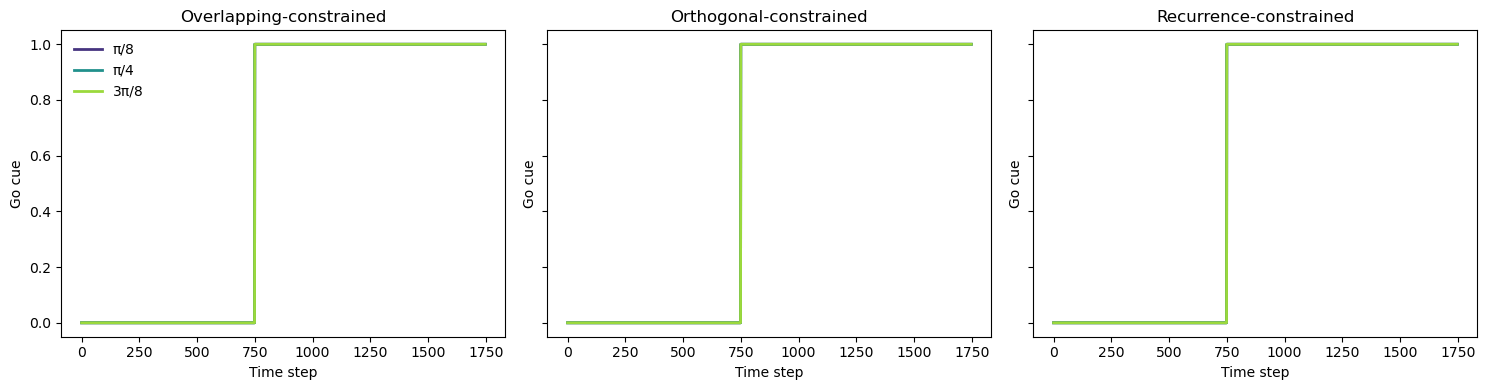

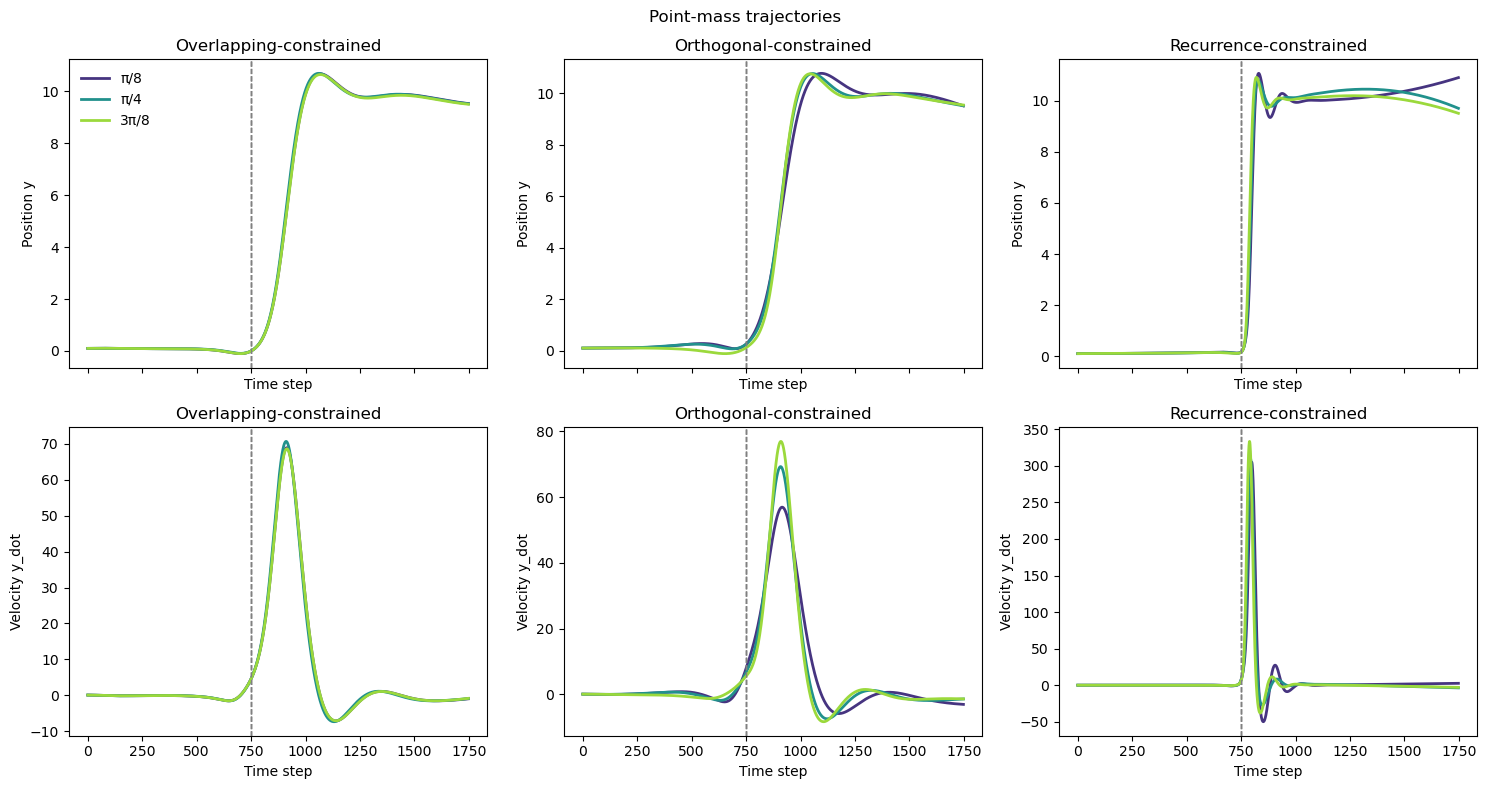

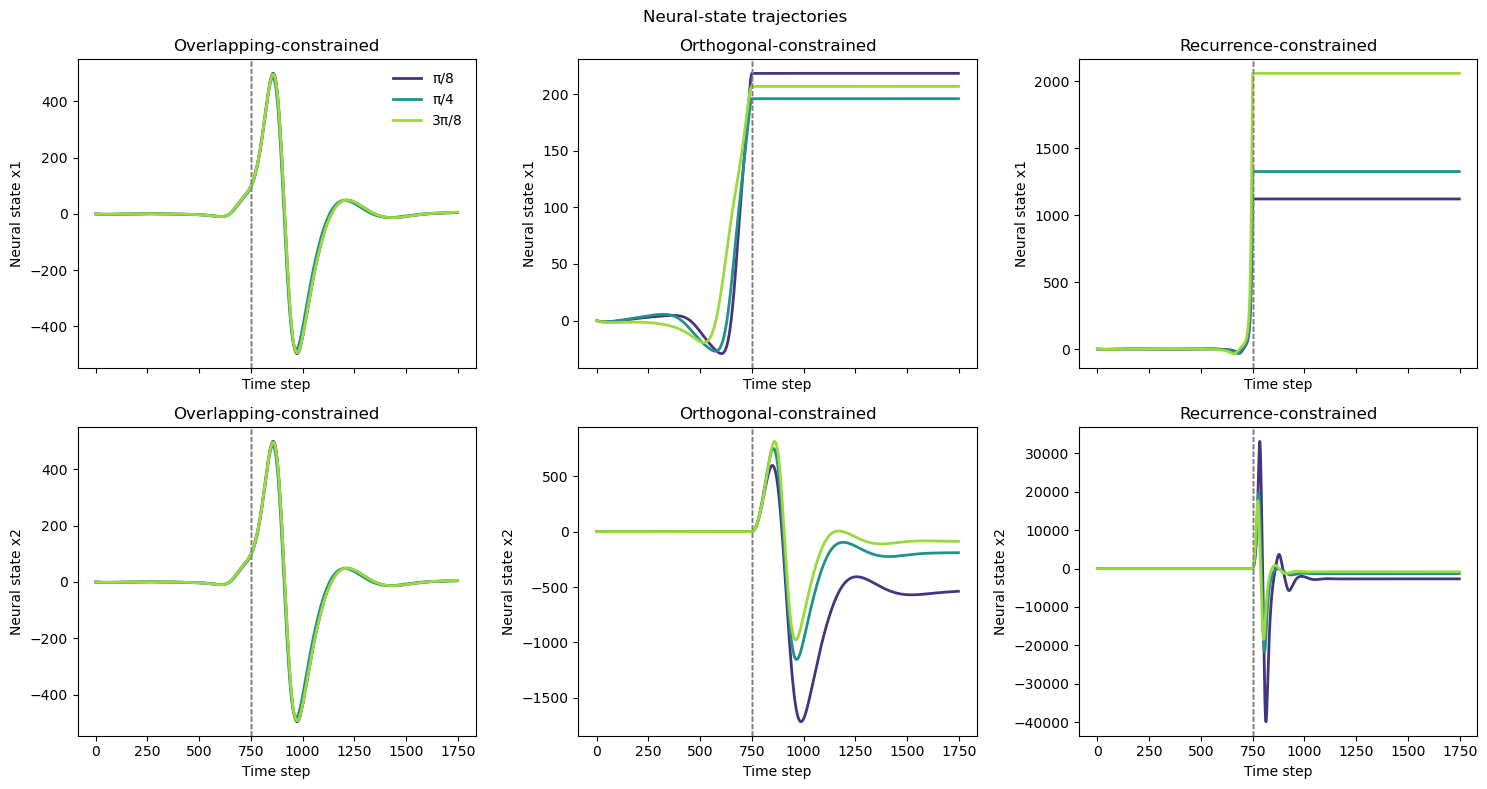

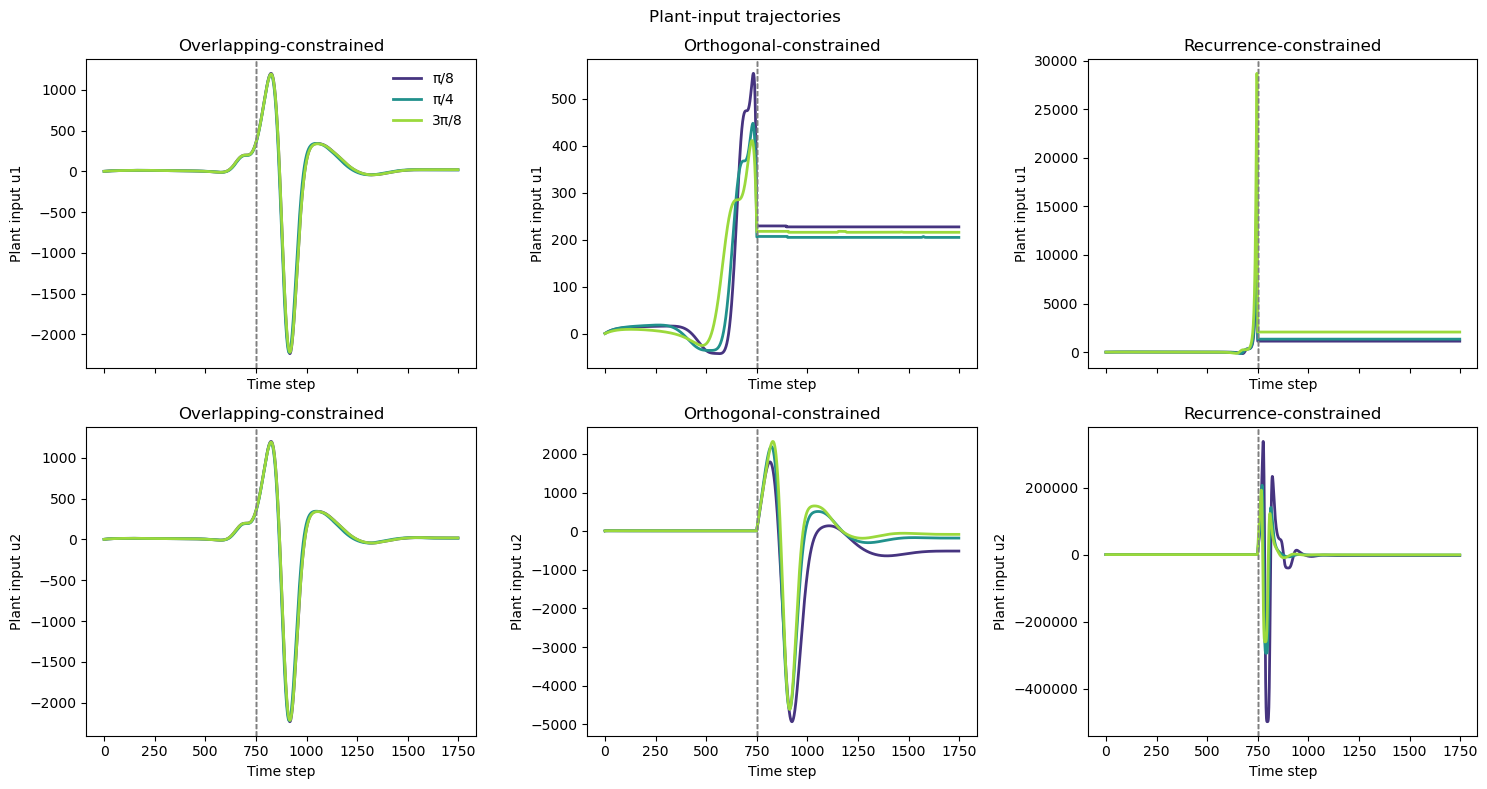

In [4]:
colors = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(angle_indices)))


def movement_onset(record):
    indices = np.flatnonzero(record["gocue"][:, 0] >= 0.5)
    if indices.size == 0:
        raise ValueError("go cue never becomes active")
    return int(indices[0])


def finish_figure(figure):
    figure.tight_layout()
    plt.show()


def plot_go_cues():
    figure, axes = plt.subplots(1, len(controller_types), figsize=(15, 4), sharex=True, sharey=True)
    for column, controller_name in enumerate(controller_types):
        for condition_position, condition_index in enumerate(angle_indices):
            record = data[(controller_name, condition_index)]
            axes[column].plot(record["gocue"][:, 0], color=colors[condition_position], linewidth=2.0, label=angle_labels[condition_index])
        axes[column].set_title(controller_labels[controller_name])
        axes[column].set_xlabel("Time step")
        axes[column].set_ylabel("Go cue")
    axes[0].legend(frameon=False)
    finish_figure(figure)


def plot_component_grid(variable_name, component_names, figure_title):
    figure, axes = plt.subplots(len(component_names), len(controller_types), figsize=(15, 4 * len(component_names)), squeeze=False, sharex=True)
    for column, controller_name in enumerate(controller_types):
        for condition_position, condition_index in enumerate(angle_indices):
            record = data[(controller_name, condition_index)]
            onset = movement_onset(record)
            for row, component_name in enumerate(component_names):
                axes[row, column].plot(record[variable_name][:, row], color=colors[condition_position], linewidth=2.0, label=angle_labels[condition_index])
                axes[row, column].axvline(onset, color="0.5", linestyle="--", linewidth=1.0)
                axes[row, column].set_ylabel(component_name)
                axes[row, column].set_title(controller_labels[controller_name])
                axes[row, column].set_xlabel("Time step")
    axes[0, 0].legend(frameon=False)
    figure.suptitle(figure_title)
    finish_figure(figure)


plot_go_cues()
plot_component_grid("y", ("Position y", "Velocity y_dot"), "Point-mass trajectories")
plot_component_grid("ss", ("Neural state x1", "Neural state x2"), "Neural-state trajectories")
plot_component_grid("uinput", ("Plant input u1", "Plant input u2"), "Plant-input trajectories")

## Movement-period plant-input range

For each condition, this metric is the largest component-wise peak-to-peak plant-input range after the detected go cue. Bars show controller means and points show individual angles.

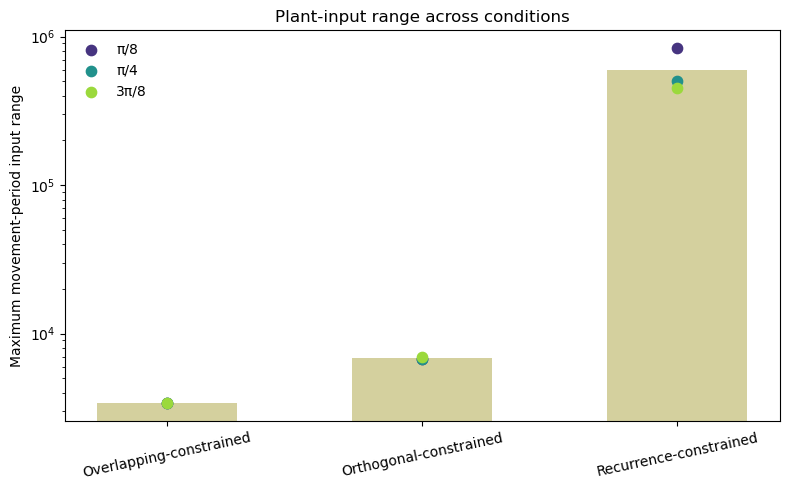

array([[  3435.79827834,   3408.34544109,   3410.86729415],
       [  6724.72648563,   6793.96963438,   6937.25901661],
       [836758.72400184, 501713.51871207, 453024.52925263]])

In [5]:
input_range = np.zeros((len(controller_types), len(angle_indices)))
for controller_position, controller_name in enumerate(controller_types):
    for condition_position, condition_index in enumerate(angle_indices):
        record = data[(controller_name, condition_index)]
        onset = movement_onset(record)
        input_range[controller_position, condition_position] = np.max(np.ptp(record["uinput"][onset:], axis=0))

figure, axis = plt.subplots(figsize=(8, 5))
positions = np.arange(len(controller_types))
axis.bar(positions, np.mean(input_range, axis=1), width=0.55, color="darkkhaki", alpha=0.65)
for condition_position, condition_index in enumerate(angle_indices):
    axis.scatter(positions, input_range[:, condition_position], color=colors[condition_position], s=55, label=angle_labels[condition_index], zorder=2)
axis.set_xticks(positions, [controller_labels[name] for name in controller_types], rotation=12)
axis.set_ylabel("Maximum movement-period input range")
axis.set_title("Plant-input range across conditions")
if np.all(input_range > 0):
    axis.set_yscale("log")
axis.legend(frameon=False)
finish_figure(figure)
input_range